In [1]:
import pandas as pd 

import numpy as np

In [2]:
df = pd.read_csv('coffee_shop_sales.csv')

In [3]:
df.head()

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,True,Credit Card,qiyfrwsk,35-44,Female,False,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,False,Debit Card,vf0jqqnv,18-24,Male,False,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,False,Mobile Wallet,fcd6mzsg,25-34,Male,False,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,False,Credit Card,jvu2cgxu,55-64,Female,True,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,False,Mobile Wallet,po4ljedg,18-24,Male,True,Sunny,12.3,New Year's Day,3.42


In [4]:
df.shape

(20000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      20000 non-null  int64  
 1   timestamp           20000 non-null  object 
 2   store_id            20000 non-null  int64  
 3   city                20000 non-null  object 
 4   country             20000 non-null  object 
 5   store_type          20000 non-null  object 
 6   product_category    20000 non-null  object 
 7   product_name        20000 non-null  object 
 8   unit_price          20000 non-null  float64
 9   quantity            20000 non-null  int64  
 10  discount_applied    20000 non-null  bool   
 11  payment_method      20000 non-null  object 
 12  customer_id         20000 non-null  object 
 13  customer_age_group  18924 non-null  object 
 14  customer_gender     18928 non-null  object 
 15  loyalty_member      20000 non-null  bool   
 16  weat

In [6]:
df.isnull().sum()

transaction_id            0
timestamp                 0
store_id                  0
city                      0
country                   0
store_type                0
product_category          0
product_name              0
unit_price                0
quantity                  0
discount_applied          0
payment_method            0
customer_id               0
customer_age_group     1076
customer_gender        1072
loyalty_member            0
weather_condition       978
temperature_c           978
holiday_name          19665
total_amount              0
dtype: int64

In [7]:
# fill in missing values
df['customer_age_group'] = df['customer_age_group'].fillna('Unknown')
df['customer_gender'] = df['customer_gender'].fillna('Unknown')
df['weather_condition'] = df['weather_condition'].fillna('Unknown')
df['holiday_name'] = df['holiday_name'].fillna('None')

# Fill numeric missing values
df['temperature_c'] = df['temperature_c'].fillna(df['temperature_c'].median())


The replacement of missing values in the database involves filling gaps in a way that ensures the consistent and usability of the data. In the situation of categorical variables such as customer_age_group, customer_gender, and weather_condition, the filling the missing value process was done using the value "Unknown," therfore avoiding the exclusion of rows and indicating the absence of the data point. In the field of holiday_name, where data was missing from almost the whole dataset, the process was carried out through adding in the value "None," telling us the fact that most transactions were made in a period where no holidays took place. Finally, the missing values in the numerical variable, temperature_c, were filled using the median value.

# Descriptive Questions


How do people’s demographics, store characteristics, and weather conditions affect global sales?
- When are the most drinks sold?
- Most popular drink by gender? age?
- Do more drinks get sold on a holiday?
- Under what weather conditions do the most drinks get sold?


C:\Users\Gabri\AppData\Local\Temp\ipykernel_8856\1343657683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='customer_age_group', y='total_amount', order=['18-24', '25-34', '35-44', '45-54', '55-64', '65+',], estimator='mean', errorbar=None, palette="viridis")


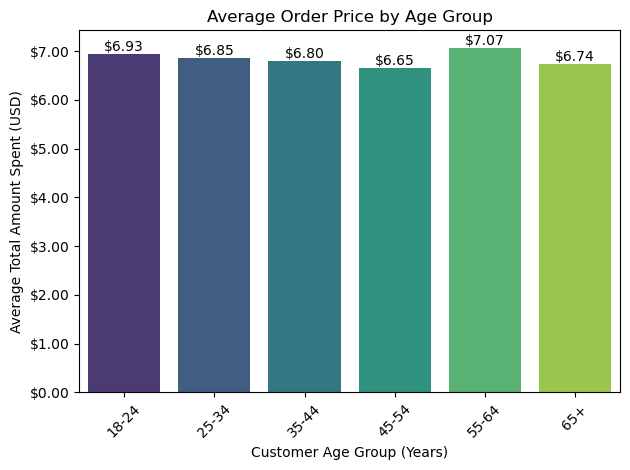

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.barplot(data=df, x='customer_age_group', y='total_amount', order=['18-24', '25-34', '35-44', '45-54', '55-64', '65+',], estimator='mean', errorbar=None, palette="viridis") 
for container in plt.gca().containers: #adding $ to each bar
    plt.bar_label(container, fmt='$%.2f')
plt.gca().yaxis.set_major_formatter('${x:1.2f}') #adding $ to y-axis
plt.title("Average Order Price by Age Group")
plt.xlabel("Customer Age Group (Years)")
plt.ylabel("Average Total Amount Spent (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

# Description
This chart shows the mean total spending made by the customers belonging to various age groups. Each bar shows the average cost of an order aquired by a customer from each age group per transaction.
# Results
In the results the graph shows us a clear age demographic in spending across age groups. Some age groups spend a bit more per transaction, while others spend less. Typically, older age groups tend to have slightly higher average spending, while younger groups may spend less per visit.
# Our interpretation 
From the chart above, it can be seen that there is consistency in the age brackets for the average amount spent per transaction. The bracket of ages 55-64 years, on the other hand, has the higheer average amount spent compared to the other age brackets. Age plays a critical role in determining how much a person spends during a transaction. Overall, the pattern shows that age does influence spending, but not dramatically.

## By Gender

In [9]:
df_filtered = df[df[:] != 'Unknown'] #Remove rows with unknown in it

Text(0.5, 1.0, 'Gender Distribution')

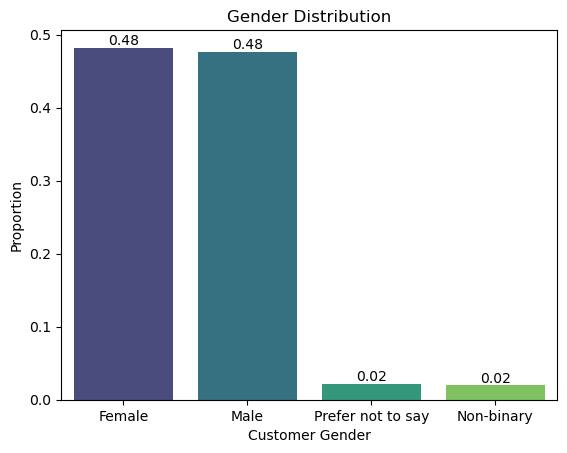

In [10]:
# Gender Statistics

counts = df_filtered['customer_gender'].value_counts(normalize=True)

sns.barplot(
    x=counts.index,
    y=counts.values,
    palette='viridis',
    hue = counts.index
)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f')

plt.ylabel("Proportion")
plt.xlabel("Customer Gender")
plt.title("Gender Distribution")

# Description
The chart below shows the distribution of customers based of their gender, which are classified into four groups: Female, Male, Non-binary, and Other. The chart shows the distribution of each gender in relation to the total number of customers.
# Results
From the findings above, it is shows that females and males are by far the largest majority in the database; each consists roughly 48 percent of the total customers. On the other hand, people who identify themselves as non-binary or choose not to reveal their gender total up to just under 2 percent each. It can be concluded from the findings that the database is strongly skewed towards two genders.
# Our Interpretation
From the gender breakdown, there appears to be an even balance in customer participation, with males and females playing an almost equal role in customer activity levels. The low percentages of Non-Binary and Prefer-not-to-say customers point towards limited participation by these customers, whether this is due to demographic trends or data gathering. Generally speaking, the graph presents a gender customer base that is mostly on the two main variables, with little to no other variation.

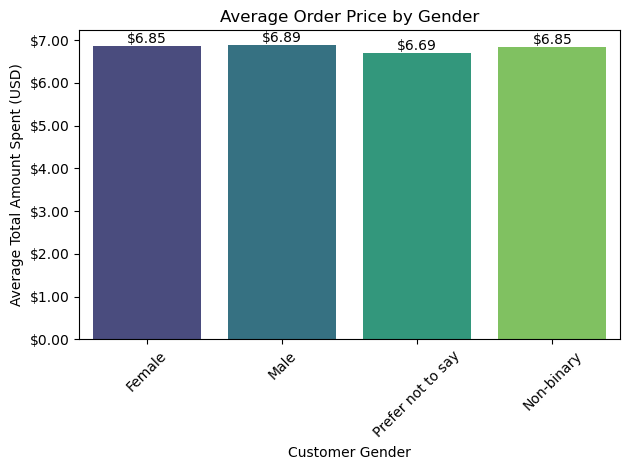

In [11]:
#Order Price by Gender



sns.barplot(data=df_filtered, x='customer_gender', y='total_amount', estimator='mean', errorbar=None, palette="viridis", hue = 'customer_gender', legend=False) 
for container in plt.gca().containers: #adding $ to each bar
    plt.bar_label(container, fmt='$%.2f')
plt.gca().yaxis.set_major_formatter('${x:1.2f}') #adding $ to y-axis
plt.title("Average Order Price by Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Average Total Amount Spent (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

# Description
In this graph, we see the average amount spent during each transaction made by people belonging to four different genders: Female, Male, Non-binary, and Prefer not to say. Each bar in this graph represents the mean order value of the customers who belong to the particular gender category.
# Results
The findings indicate that Male clients have the highest mean order price of 6.89, while those who identify as Female and Non-binary follow closely at 6.85 each. Clients that do not prefer not to say their gender tend to spend the least on average at 6.69. The variations across all groups are minimal, but there is an observable upward trend in Male clients' spending.
# Our Interpretation 
According to the graph, gender seems to play a small role when it comes to average spendings, since all the figures are within a similar range regardless of the category. Males tend to have higher average total amount of spending than females, whereas those who do not wish to declare have slightly lower average expenditures.

Most popular orders for Female:
Croissant: 317
Scone: 311
Medium Latte: 311

Most popular orders for Male:
Medium Americano: 306
Medium Cappuccino: 305
Double Espresso: 303

Most popular orders for nan:

Most popular orders for Prefer not to say:
Small Latte: 21
Large Latte: 17
Chicken & Avocado Wrap: 17

Most popular orders for Non-binary:
Chicken & Avocado Wrap: 19
Small Americano: 16
Medium Latte: 15



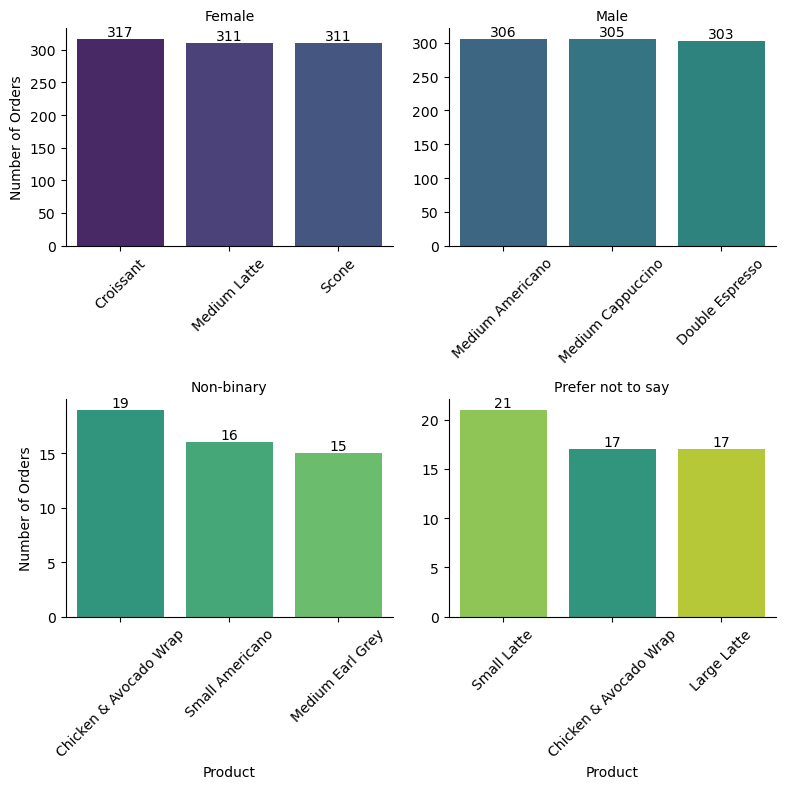

In [12]:
# Find the most popular drink by gender

for gender in df_filtered['customer_gender'].unique():
    print(f"Most popular orders for {gender}:")
    top_items = df_filtered[df_filtered['customer_gender'] == gender]['product_name'] \
    .value_counts().head(3)
    for item, count in top_items.items():
        print(f"{item}: {count}")
    print()



top_products = (
    df_filtered
    .groupby('customer_gender')['product_name']
    .value_counts()
    .groupby(level=0)
    .head(3)
    .reset_index(name='count')
)

g = sns.catplot(
    data=top_products,
    x='product_name',
    y='count',
    col='customer_gender',
    kind='bar',
    col_wrap=2,
    sharex=False,
    sharey=False,
    palette='viridis',
    height=4,
    hue = 'product_name',
    legend=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Product", "Number of Orders")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

# Description
This graph tells us the best-selling three items for each category of gender, such as Female, Male, Non-binary, and Prefer not to say. The related charts in the form of bars represent the amount of order for each of these top products, making it easier to compare preferences among genders.
# Results
The female customers' top choices included Croissants (317), Scones (311), and Medium Lattes (311). In contrast, male customers tended to choose products that contained coffee, and their top three picks included Medium Americanos (306), Medium Cappuccinos (305), and Double Espressos (303). Gender unknown individuals were partial to Small Lattes (21), Large Lattes (17), and Chicken & Avocado Wraps (17). For non-binary customers, the three most preferred products included Chicken & Avocado Wraps (19), Small Americanos (16), and Medium Lattes (15).
# Our Interpretation 
From the findings, it tells us that there is some influence of gender on the choice of products. Women clients have a higher inclination towards pastries and drinks that are relatively balanced, whereas men are likely to choose for a stronger coffee-based drink. The non-binary group of people and those who would rather not specify have more diverse orders, comprising both drinks and foods among the preferred items.

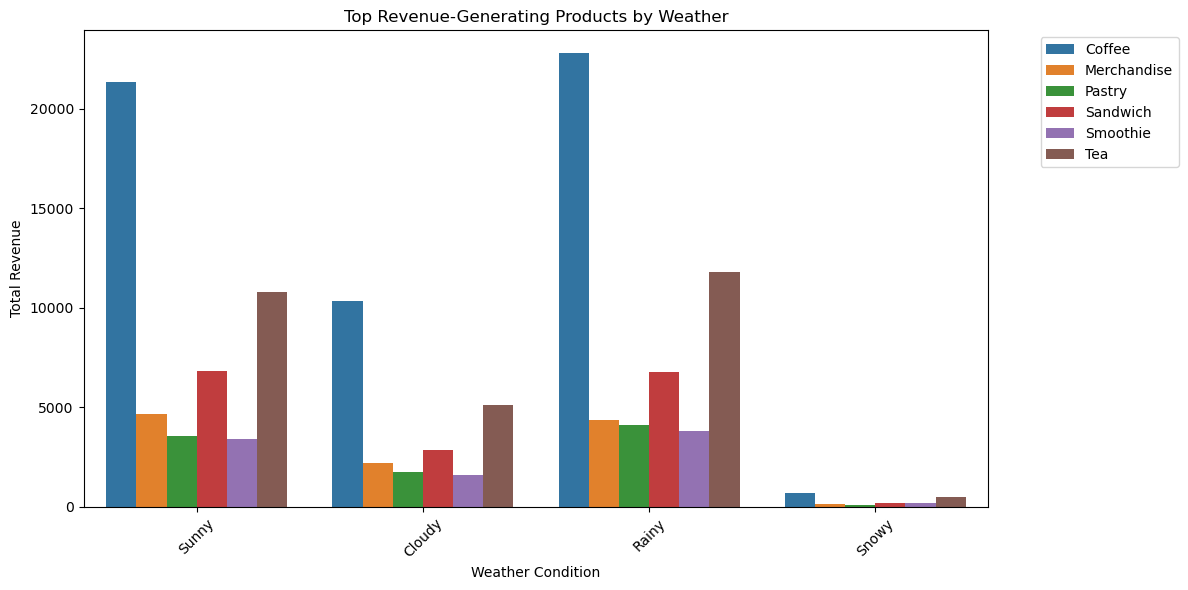

In [13]:
# Top Products by weather condition

top_weather_products = (
    df_filtered
    .groupby(['weather_condition', 'product_category'], as_index=False)['total_amount']
    .sum()
)

weather_order = ['Sunny', 'Cloudy', 'Rainy', 'Snowy']

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_weather_products,
    x='weather_condition',
    y='total_amount',
    hue='product_category',
    order=weather_order
)

plt.title("Top Revenue-Generating Products by Weather")
plt.ylabel("Total Revenue")
plt.xlabel("Weather Condition")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Description
The chart shows the sum of the income earned from various types of products based on the following weather types: Sunny, Cloudy, Rainy, and Snowy. This chart is used to indicate the sum of revenues obtained from various types of products per weather type.
# Results
From the analysis above, it can be seen that Coffee brings in more revenue under all weather conditions. It is followed by Pastries and Sandwiches whose performance is relatively good but changes with changing weather conditions. The smallest shares in income are brought in by Merchandise, Smoothies, and Tea. Their performance does not change greatly with weather.
# Our interpretation
From the results of the data analysis, it is possible to assume that weather affects customers' purchase decisions, including those related to beverage types. The consistent performance of coffee in all types of weather shows its profitability for most occasions but seems to be higher when it is either sunny or rainy weather. Meanwhile, other types, like Pastries and Sandwiches, are affected by weather changes by a lot, most likely because the customers are mood-dependent and change their preference with weather changes.

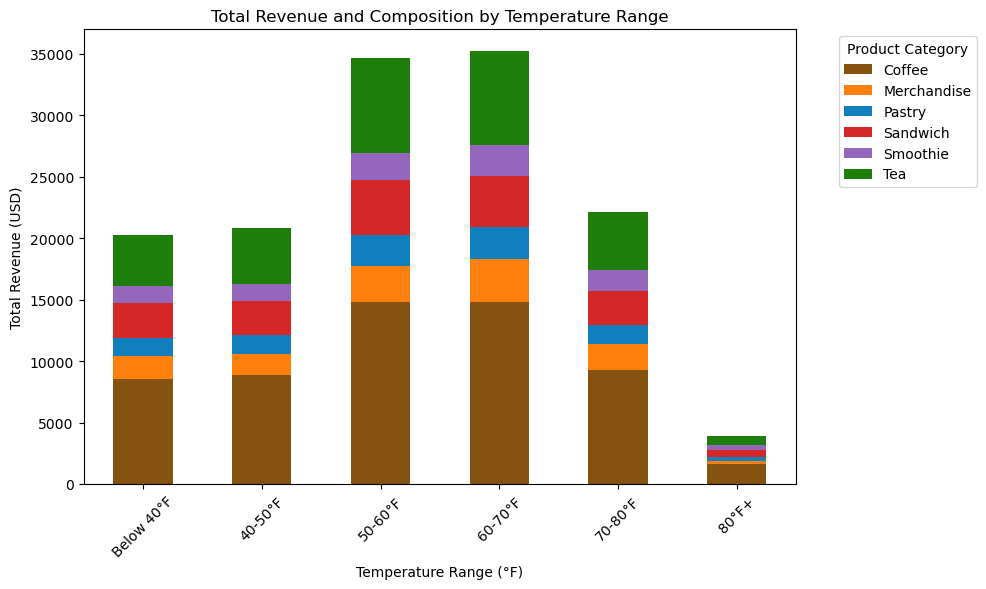

In [14]:
# add column to the filtered DataFrame
df_filtered['temp_range'] = pd.cut(
    df_filtered['temperature_c'],
    bins=[-15, 4.5, 10, 15.5, 21.1, 26.6, 32.2],
    labels=['Below 40°F', '40-50°F', '50-60°F', '60-70°F', '70-80°F', '80°F+']
)

# Order data with pandas before graphing cause otherwise it is a pain
temp_category_revenue = (
    df_filtered
    .groupby(['temp_range', 'product_category'], observed=True, as_index=False)['total_amount']
    .sum()
)

# Create a pivot table for easier plotting
pivot_df = temp_category_revenue.pivot(
    index='temp_range',
    columns='product_category',
    values='total_amount'
).fillna(0)

#plot the pivot table
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=["#855210", "#ff7f0e", "#117fbe", "#d62728", "#9467bd", "#1d7e0a"]
)

plt.title("Total Revenue and Composition by Temperature Range")
plt.xlabel("Temperature Range (°F)")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Description
The following figure displays the total revenue earned in various temperatures, ranging from less than 40°F to more than 80°F. The bars are further categorized into various products, including Coffee, Merchandise, Pastry, Sandwich, Smoothie, and Tea. Thus, this visualization provides insight into both the total revenue earned and how the product mix varies based on temperature zones.
# Results
From the findings above, it is clear that total income is at its maximum level within the temperature ranges 50-70 °F. These temperature ranges makes the highest revenues for almost all products. Coffee, which is a consistent product to total income for each temperature range, has the highest percentage share in total income. Pastries and Sandwiches have a high contribution to the income during average temperatures. Income levels fall a lot because beyond 80 °F temperatures, and income is lower below 40 °F temperatures.
# Our Interpretation
Based on the graph, the best sales occurs when the temperatures range between 50–70°F. This is probably because such temperatures affect people who are doing outdoor activities and visits to the cafe. Coffee still represents the major source of income at any temperature, but it is particularly common at the higher temperatures when the total orders seems to be the highest. The reduction in income during high and low temperatures may be because the customers do not prefer visiting the cafe when the weather is too much.

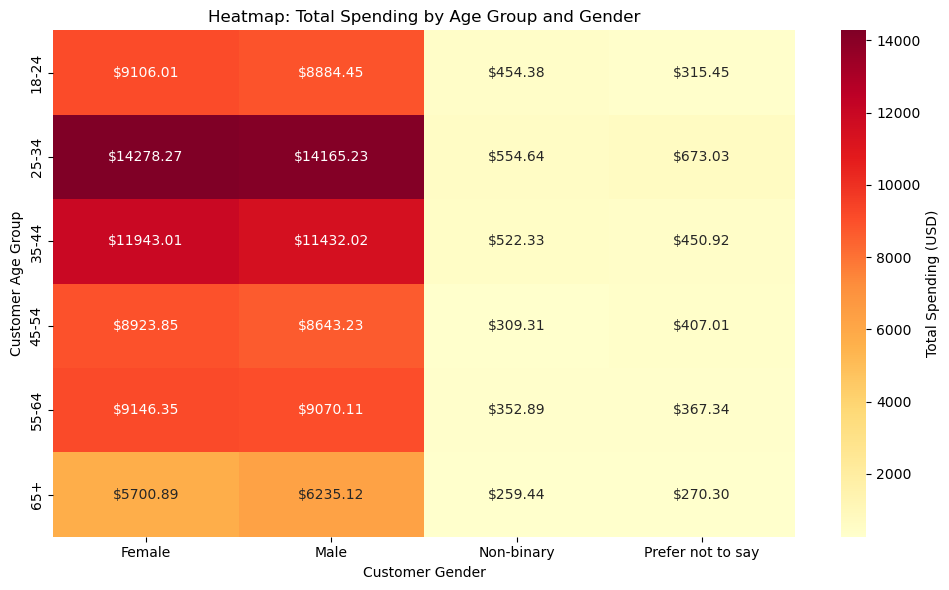


Highest Spending Combination: 25-34 (Gender: Female) - $14,278.27


In [15]:
# Heatmap: Total Spending by Age Group and Gender

# Create a crosstab showing total spending across age groups and genders
spending_pivot = pd.crosstab(
    df['customer_age_group'],
    df_filtered['customer_gender'],
    values=df['total_amount'],
    aggfunc='sum'
)

# Reorder age groups logically
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
spending_pivot = spending_pivot.reindex([age for age in age_order if age in spending_pivot.index]) 

# Create heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(data = spending_pivot, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Total Spending (USD)'})
for t in ax.texts:
    t.set_text('$' + t.get_text())
plt.title("Heatmap: Total Spending by Age Group and Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Customer Age Group")
plt.tight_layout()
plt.show()

# Find the age group and gender combination with highest spending
max_spending_idx = spending_pivot.stack().idxmax()
max_spending_value = spending_pivot.stack().max()
print(f"\nHighest Spending Combination: {max_spending_idx[0]} (Gender: {max_spending_idx[1]}) - ${max_spending_value:,.2f}")

# Description
Heatmap of Revenue Spent by Customers based on Age Group and Gender
The above heatmap shows spending amounts among different mixes of customer demographics according to their ages and genders. The value in each box is the amount of revenue earned from that particular demographic.
# Results
From our findings, it is proof that the largest total amount of spending occurs within customers in the 25-34 years bracket, especially Female ($$14,165.23) consumers. Others are the 35-44 year bracket, where both the Female and Male consumers spend more than $11,000. The Non-binary and Prefer not to say consumer boxes mainly register smaller total spending in all age brackets, considering they make a small part of the data set. Generally, most of the spending occurs between 25-44 years, while the lowest occurs in other age brackets.
# Our Interpretation 
From the heatmap, age seems to be one of the main variables affecting total sales, given that the customers aged 25 through 44 have the highest sales contribution based of their gender type. It tells us from the heatmap that female and male types contribute most to total sales owing to both high occurrence and transaction levels, while non-binary and prefer-not-to-say contribute to lower sales. High sales by the 25 through 34 age group means that this is the key customer base that is mostly what makes the most attention to coffee shops.

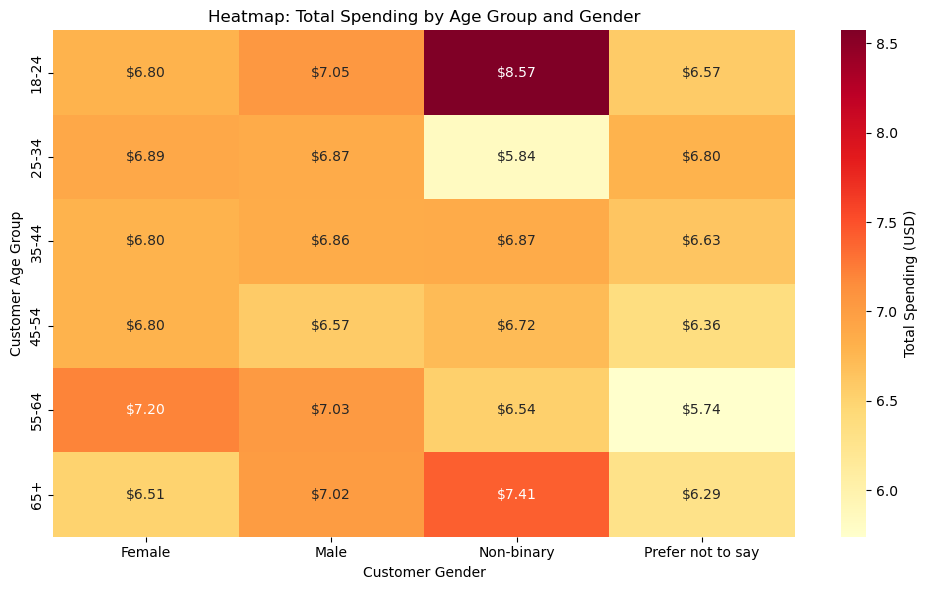


Highest Spending Per Order: 18-24 (Gender: Non-binary) - $8.57


In [16]:
# Create a crosstab showing total spending across age groups and genders
spending_pivot = pd.crosstab(
    df['customer_age_group'],
    df_filtered['customer_gender'],
    values=df['total_amount'],
    aggfunc='mean'
)

spending_pivot = spending_pivot.reindex([age for age in age_order if age in spending_pivot.index]) 

# Create heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(data = spending_pivot, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Total Spending (USD)'})
for t in ax.texts:
    t.set_text('$' + t.get_text())
plt.title("Heatmap: Total Spending by Age Group and Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Customer Age Group")
plt.tight_layout()
plt.show()

# Find the age group and gender combination with highest spending
max_spending_idx = spending_pivot.stack().idxmax()
max_spending_value = spending_pivot.stack().max()
print(f"\nHighest Spending Per Order: {max_spending_idx[0]} (Gender: {max_spending_idx[1]}) - ${max_spending_value:,.2f}")

# Description
The heat map tells us the spending amount per order by different combinations of customer age categories and their genders. Every cell is the mean spending amount made by a certain category, where the color intensity corresponds to the higher spending amount. This chart helps to compare which age and gender categories have higher spending per transaction.
# Results
The results show that the highest average spending per order comes from customers aged 18–24 who identify as Non‑binary, with an average of 8.57. Most other age–gender groups fall within a smaller range of average spending, generally between 6.50 and 7.50 per order. Female and Male customers across all age groups show similar spending patterns, while Non‑binary and Prefer‑not‑to‑say groups display more variation due to smaller data sizes.
# Our Interpretation
From the graph, it can be seen even though there is not much  a difference between the average amount spent by different demographics, there are some particular smaller demographics such as “Non-binary” customers between the age group 18-24 years that are showing some of the higher average amounts of spending. Overall, from the graph, it can be seen that the average amount of money spent by different age and gender groups is more or less the same.